imports


In [126]:
import os
from getpass import getpass
import pandas as pd
from PIL import Image
from IPython.display import display
import fitz
from groq import Groq
from pinecone import Pinecone, ServerlessSpec
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_pinecone import PineconeVectorStore


In [127]:

import os
import io
import time
import base64
from pathlib import Path
from getpass import getpass
import fitz
import pandas as pd
from PIL import Image
from IPython.display import display
from groq import Groq

In [128]:
pdf_path=Path("data.pdf")
#if file not exist so we use fallback where 
#same file stored at differenr place and uses that file
if not pdf_path.exists():
      fallback=Path("../data.pdf")
      if fallback.exists ():
          pdf_path=fallback

assert pdf_path.exists(),(
    "pdf not found in another folder too"
)           


In [129]:
pdf_path

WindowsPath('data.pdf')

In [130]:
text_model="openai/gpt-oss-20b"
vision_model="qwen/qwen3.8-27b"
embedding_model="senetence-transformers/all-MiniLM-L6-v2"

In [131]:
pinecone_index_name="multimodal-rag"
pinecone_namespace="demo_fy2026"
image_dir=Path("images")
image_dir.mkdir(exist_ok=True)



In [132]:
print(pdf_path)

data.pdf


In [133]:
print(pinecone_index_name)

multimodal-rag


In [134]:
#adding api keysimport os
from dotenv import load_dotenv

load_dotenv()

grok_api_key = os.getenv("grok_api_key")
pinecone_api_key = os.getenv("pinecone_api_key")



In [135]:
#checking whether api keys loaded are not
print("Groq key loaded: - main.ipynb:2", bool(grok_api_key))
print("Pinecone key loaded: - main.ipynb:3", bool(pinecone_api_key))
groq_client = Groq(api_key=grok_api_key)


Groq key loaded: - main.ipynb:2 True
Pinecone key loaded: - main.ipynb:3 True


In [136]:
text_llm = ChatGroq(
    model=text_model,
    temperature=0,
    api_key=grok_api_key
)

In [137]:
pc = Pinecone(api_key=pinecone_api_key
              )

In [138]:
print(pinecone_index_name)
print(pc.list_indexes())

multimodal-rag
[{
    "name": "multimodal-rag",
    "metric": "cosine",
    "host": "multimodal-rag-w78vv60.svc.aped-4627-b74a.pinecone.io",
    "spec": {
        "serverless": {
            "cloud": "aws",
            "region": "us-east-1"
        }
    },
    "status": {
        "ready": true,
        "state": "Ready"
    },
    "vector_type": "dense",
    "dimension": 384,
    "deletion_protection": "disabled",
    "tags": null
}]


In [139]:
index = pc.Index(pinecone_index_name)

In [140]:
##converting image to base64 code
def image_to_uri(image_path):
     image_path=Path(image_path)
     with Image.open(image_path) as img :
         img=img.convert("RGB")
         img.thumbnail((1600,1600))
         buffer=io.BytesIO()
         img.save(buffer,format="JPEG",quality=85)
     encoded=base64.b64encode(buffer.getvalue()).decode("utf-8")
     return f"data:image/jpeg;base64,{encoded}"

In [141]:
#helper to summarize charts and graphs
def summarize_visual(image_path,page_number):
    image_data=image_to_uri(image_path)
    
    prompt =  f"""
          This visual was extracted from page{page_number} of the data. 
          Describe the useful business information visible in the visual.
          If it is  a chart or graph:
             -mention improvement values
             -mention highest/lowest values
             -mention the main trend
          If it is a diagram :
             -identify important componenets
             -explain the flow or relationships
         
          If it is a normal business image:
            -describe the useful factual in formation
          Keep the description concise and factual"""
          
    response=groq_client.chat.completions.create(
              model=vision_model,
             messages=[
                 {
                     "role":"user",
                     "content":[
                         {
                             "type":"text","text": prompt},
                     {
                         "type":"image_url",
                         "image_url":{"url":image_data},
                         
                     },
                     ],
                 }
             ] ,
             temperature=0,
             max_completion_tokens=500,
          )
    return response.choices[0].message.content.strip()

Extraxting text , images, graphs from pdf

In [142]:
def extrack_multimodal_documents(pdf_path):
    pdf=fitz.open(str(pdf_path))
    documents=[]
    extracted_xrefs=set()
    for page_index in range(len(pdf)):
        page=pdf[page_index]
        page_number=page_index+1
        print(f"processing page {page_number }... - main.ipynb:8")
        
        # 1. text
        text=page.get_text("text").strip()
        if text :
            documents.append(
                Document(
                    page_content=text,
                    metadata={
                        "page":page_number,
                        "modality":"text",
                        "source":pdf_path.name,
                    },
                )
            )
            ##tables data
         
        try:
            tables = page.find_tables().tables

            for table_number, table in enumerate(tables, start=1):
                df = table.to_pandas()

                if not df.empty:
                    table_text = df.to_markdown(index=False)

                    documents.append(
                        Document(
                            page_content=table_text,
                            metadata={
                                "page": page_number,
                                "modality": "table",
                                "table_number": table_number,
                                "source": pdf_path.name,
                            },
                        )
                    )

        except Exception as error:
            print("Table extraction warning: - main.ipynb:47", error)

        # -------------------------------------------------
        # 3. IMAGES / CHARTS / DIAGRAMS
        # -------------------------------------------------
        for image_number, image_info in enumerate(
            page.get_images(full=True),
            start=1,
        ):
            xref = image_info[0]

            # Do not process an identical embedded image twice.
            if xref in extracted_xrefs:
                continue

            extracted_xrefs.add(xref)

            image_data = pdf.extract_image(xref)
            image_bytes = image_data["image"]
            image_extension = image_data["ext"]

            image_path = (
                image_dir
                / f"page_{page_number}_image_{image_number}.{image_extension}"
            )
            image_path.write_bytes(image_bytes)
            try:
                summary = summarize_visual(
                    image_path=image_path,
                    page_number=page_number,
                )
                documents.append(
                    Document(
                        page_content=summary,
                        metadata={
                            "page": page_number,
                            "modality": "visual",
                            "image_path": str(image_path),
                            "source": pdf_path.name,
                        },
                    )
                )

            except Exception as error:
                print(
                    f"Vision warning on page {page_number}:",
                    error,
                )

    pdf.close()
    return documents


documents = extrack_multimodal_documents(pdf_path)

print()
print("Total LangChain documents: - main.ipynb:103", len(documents))   

processing page 1... - main.ipynb:8
processing page 2... - main.ipynb:8
processing page 3... - main.ipynb:8
processing page 4... - main.ipynb:8
processing page 5... - main.ipynb:8
processing page 6... - main.ipynb:8
processing page 7... - main.ipynb:8
processing page 8... - main.ipynb:8
processing page 9... - main.ipynb:8

Total LangChain documents: - main.ipynb:103 24


In [143]:
documents
 

[Document(metadata={'page': 1, 'modality': 'text', 'source': 'data.pdf'}, page_content='NovaCore Systems Ltd. - Fictional company report created for a multimodal RAG demonstration\nPage 1\nNOVACORE SYSTEMS LTD.\nFY2026 BUSINESS PERFORMANCE &\nOPERATIONS REPORT\nA realistic fictional company document designed for multimodal RAG testing\nHeadquarters\nSingapore\nEmployees\n1,480\n2026 Revenue\n$132.0M\nOperating Margin\n18.4%\nPrimary Sector\nIndustrial AI & IoT\nMarkets Served\n42 countries\nDemo note: All company names, metrics, people, and events in this report are fictional. The document intentionally mixes text, tables,\ncharts, and embedded images so it can be used to demonstrate multimodal retrieval and question answering.'),
 Document(metadata={'page': 1, 'modality': 'table', 'table_number': 1, 'source': 'data.pdf'}, page_content='| Headquarters   | Singapore           | Employees        | 1,480        |\n|:---------------|:--------------------|:-----------------|:-------------|\

Inspect extracted content

In [144]:
rows = []

for doc in documents:
    rows.append(
        {
            "page": doc.metadata["page"],
            "modality": doc.metadata["modality"],
            "preview": doc.page_content[:140].replace("\n", " "),
        }
    )

summary_df = pd.DataFrame(rows)

display(summary_df)

print("Documents by modality: - main.ipynb:16")
display(summary_df["modality"].value_counts())

,page,modality,preview
0,1,text,NovaCore Systems Ltd. - Fictional company repo...
1,1,table,| Headquarters | Singapore | Emplo...
2,1,visual,"Based on the visual provided, here is the desc..."
3,2,text,NovaCore Systems Ltd. - Fictional company repo...
4,2,table,| Priority | 2026 target ...
5,3,text,NovaCore Systems Ltd. - Fictional company repo...
6,3,table,| Metric | FY2025 | FY2026 | Cha...
7,3,visual,"Based on the provided visual, here is the desc..."
8,4,text,NovaCore Systems Ltd. - Fictional company repo...
9,4,table,| Region | 2026 revenue | YoY growth ...


Documents by modality: - main.ipynb:16


modality
text      9
table     8
visual    7
Name: count, dtype: int64

In [145]:
#creating embeddings
embedding_model = "sentence-transformers/all-MiniLM-L6-v2"

embeddings = HuggingFaceEmbeddings(
    model_name=embedding_model,
    encode_kwargs={"normalize_embeddings": True},
)

# Detect the exact vector dimension automatically.
EMBEDDING_DIMENSION = len(
    embeddings.embed_query("dimension check")
)

print("Embedding model: - main.ipynb:14", embedding_model)
print("Embedding dimension: - main.ipynb:15", EMBEDDING_DIMENSION)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3658.18it/s]


Embedding model: - main.ipynb:14 sentence-transformers/all-MiniLM-L6-v2
Embedding dimension: - main.ipynb:15 384


In [146]:

##creating pine cone index if not exist

pc = Pinecone(
    api_key=os.environ["pinecone_api_key"]
)

if not pc.has_index(pinecone_index_name):
    print("Creating Pinecone index... - main.ipynb:9")

    pc.create_index(
        name=pinecone_index_name,
        dimension=EMBEDDING_DIMENSION,
        metric="cosine",
        spec=ServerlessSpec(
            cloud="aws",
            region="us-east-1",
        ),
    )

    # Wait until Pinecone reports that the index is ready.
    while not pc.describe_index(pinecone_index_name).status["ready"]:
        print("Waiting for Pinecone index... - main.ipynb:23")
        time.sleep(2)

    print("Pinecone index created. - main.ipynb:26")
else:
    print("Pinecone index already exists. - main.ipynb:28")
    
index = pc.Index(pinecone_index_name)

print("Connected to: - main.ipynb:32", pinecone_index_name)
     

Pinecone index already exists. - main.ipynb:28
Connected to: - main.ipynb:32 multimodal-rag


In [147]:
##clean the vector because if any duplicate  exist
try:
    index.delete(
        delete_all=True,
        namespace=pinecone_namespace,
    )
    print("Cleared namespace: - main.ipynb:7", pinecone_namespace)
except Exception as error:
    print(
        "Namespace  empty. Continuing...",
        error,
    )

Cleared namespace: - main.ipynb:7 demo_fy2026


In [148]:

# Store LangChain documents into Pinecone without duplicates

# 1. Create Pinecone vector store
vectorstore = PineconeVectorStore(
    index_name=pinecone_index_name,
    embedding=embeddings,
    namespace=pinecone_namespace,
)
# Create stable IDs for each document
document_ids = []
for i, doc in enumerate(documents):
    doc_id = (
        f"{doc.metadata['source']}"
        f"_page_{doc.metadata['page']}"
        f"_{doc.metadata['modality']}"
        f"_{i}"
    )

    document_ids.append(doc_id)


#  Check which document IDs already exist in Pinecone
existing_ids = set()
# Pinecone fetch works with batches, so check 100 IDs at a time
for i in range(0, len(document_ids), 100):
    batch_ids = document_ids[i:i + 100]
    result = index.fetch(
        ids=batch_ids,
        namespace=pinecone_namespace
    )
    existing_ids.update(result.vectors.keys())

# Keep only documents that are NOT already in Pinecone
new_documents = []
new_ids = []
for doc, doc_id in zip(documents, document_ids):
    if doc_id not in existing_ids:
        new_documents.append(doc)
        new_ids.append(doc_id)

# 5. Upload only new documents
if new_documents:
    vectorstore.add_documents(
        documents=new_documents,
        ids=new_ids
    )
    print(f"Uploaded {len(new_documents)} new documents to Pinecone. - main.ipynb:48")
else:
    print("All documents already exist in Pinecone. Nothing uploaded. - main.ipynb:50")

# Show 
print("Total documents: - main.ipynb:53", len(documents))
print("Already existed: - main.ipynb:54", len(existing_ids))
print("New documents: - main.ipynb:55", len(new_documents))

Uploaded 24 new documents to Pinecone. - main.ipynb:48
Total documents: - main.ipynb:53 24
Already existed: - main.ipynb:54 0
New documents: - main.ipynb:55 24


In [149]:
##create retriever
retriever=vectorstore.as_retriever(
    search_kwargs={"k":5}
)
print("retriever is ready - main.ipynb:5")

retriever is ready - main.ipynb:5


In [150]:
retriever

VectorStoreRetriever(tags=['PineconeVectorStore', 'HuggingFaceEmbeddings'], vectorstore=<langchain_pinecone.vectorstores.PineconeVectorStore object at 0x0000017151EC0050>, search_kwargs={'k': 5})

In [151]:
##testing pinecone
query="which region has heighest revenue growth"
retrieved_docs=retriever.invoke(query)
for i,doc in enumerate(retrieved_docs,start=1):
    print("= - main.ipynb:5"*80)
    print(
        f"result {i} |"
        f"page {doc.metadata.get('page')} |"
        f"type: {doc.metadata.get('modality')}"
    )
    print(doc.page_content[:700])
    print()

= - main.ipynb:5= - main.ipynb:5= - main.ipynb:5= - main.ipynb:5= - main.ipynb:5= - main.ipynb:5= - main.ipynb:5= - main.ipynb:5= - main.ipynb:5= - main.ipynb:5= - main.ipynb:5= - main.ipynb:5= - main.ipynb:5= - main.ipynb:5= - main.ipynb:5= - main.ipynb:5= - main.ipynb:5= - main.ipynb:5= - main.ipynb:5= - main.ipynb:5= - main.ipynb:5= - main.ipynb:5= - main.ipynb:5= - main.ipynb:5= - main.ipynb:5= - main.ipynb:5= - main.ipynb:5= - main.ipynb:5= - main.ipynb:5= - main.ipynb:5= - main.ipynb:5= - main.ipynb:5= - main.ipynb:5= - main.ipynb:5= - main.ipynb:5= - main.ipynb:5= - main.ipynb:5= - main.ipynb:5= - main.ipynb:5= - main.ipynb:5= - main.ipynb:5= - main.ipynb:5= - main.ipynb:5= - main.ipynb:5= - main.ipynb:5= - main.ipynb:5= - main.ipynb:5= - main.ipynb:5= - main.ipynb:5= - main.ipynb:5= - main.ipynb:5= - main.ipynb:5= - main.ipynb:5= - main.ipynb:5= - main.ipynb:5= - main.ipynb:5= - main.ipynb:5= - main.ipynb:5= - main.ipynb:5= - main.ipynb:5= - main.ipynb:5= - main.ipynb:5= - main

#CREATE THE LANGCHAIN TEXT RAG CHAIN


Question
   ↓
Pinecone Retriever
   ↓
Relevant Context
   ↓
Prompt
   ↓
Text LLM
   ↓
Answer

In [152]:
rag_prompt = ChatPromptTemplate.from_template(
    """
You are a helpful assistant answering questions about the
NovaCore Systems FY2026 company report.

Use ONLY the retrieved context below.

If the answer is not available in the context, say:
"I could not find that information in the report."

Mention page numbers when possible.
CONTEXT:
{context}
QUESTION:
{question}
ANSWER:
"""
)
text_rag_chain = (
    rag_prompt
    | text_llm
    | StrOutputParser()
)

print("Text RAG chain is ready. - main.ipynb:25")

Text RAG chain is ready. - main.ipynb:25


In [153]:
##retrieved context formatting
def format_context(retrieved_docs):
    parts = []

    for doc in retrieved_docs:
        page = doc.metadata.get("page")
        modality = doc.metadata.get("modality")

        parts.append(
            f"[Page {page} | {modality.upper()}]\n"
            f"{doc.page_content}"
        )

    return "\n\n".join(parts)


If Pinecone retrieves visual evidence:

Pinecone retrieves visual summary
            ↓
Read image_path from metadata
            ↓
Load the original image
            ↓
Question + context + image
            ↓
Vision model

In [154]:
def answer_with_vision(question, context, image_paths):
    image_paths = image_paths[:3]

    content = [
        {
            "type": "text",
            "text": f"""
You are answering questions about the data FY2026 report.
Use ONLY the retrieved context and the attached retrieved visuals.

Retrieved Context:
{context}

Question:
{question}

Instructions:
- Answer factually.
- Use the attached visuals when relevant.
- Mention page numbers.
- If the information is missing, say you could not find it.
""",
        }
    ]
    
    for image_path in image_paths:
        content.append(
            {
            "type": "image_url",
            "image_url": {
                "url": image_to_uri(image_path)
            },
            }
        )

    response = groq_client.chat.completions.create(
        model=vision_model,
        messages=[
            {
                "role": "user",
                "content": content,
            }
        ],
        temperature=0,
        max_completion_tokens=900,
    )

    return response.choices[0].message.content.strip()
     
    
    
    

This is the complete application:

Question
   ↓
Pinecone Retriever
   ↓
Top 5 documents
   ↓
Any visual?
   ├── No  → Text RAG chain
   └── Yes → Vision LLM + retrieved images
   ↓
Final answer

In [155]:
def ask(question, show_sources=True, show_images=False):

    # 1. Retrieve from Pinecone
    retrieved_docs = retriever.invoke(question)

    # 2. Create context
    context = format_context(retrieved_docs)

    # 3. Check whether Pinecone returned visuals
    image_paths = []

    for doc in retrieved_docs:
        if doc.metadata.get("modality") == "visual":
            image_path = doc.metadata.get("image_path")

            if image_path and Path(image_path).exists():
                image_paths.append(image_path)

    # 4. Generate the answer
    if image_paths:
        answer = answer_with_vision(
            question=question,
            context=context,
            image_paths=image_paths,
        )
    else:
        answer = text_rag_chain.invoke(
            {
                "context": context,
                "question": question,
            }
        )

    print("\nQUESTION: - main.ipynb:34")
    print(question)

    print("\nANSWER: - main.ipynb:37")
    print(answer)

    if show_sources:
        print("\nPINECONE RETRIEVED SOURCES: - main.ipynb:41")

        for i, doc in enumerate(retrieved_docs, start=1):
            print(
                f"{i}. Page {doc.metadata.get('page')} "
                f"| {doc.metadata.get('modality')}"
            )

    if show_images and image_paths:
        print("\nRETRIEVED VISUALS: - main.ipynb:50")

        for image_path in image_paths:
            display(Image.open(image_path))

    return {
        "answer": answer,
        "documents": retrieved_docs,
        "image_paths": image_paths,
    }
        


QUESTION: - main.ipynb:34
give me brief aboutNovacare 

ANSWER: - main.ipynb:37
Based on the FY2026 report, here is a brief overview of NovaCore Systems Ltd.:

**Company Overview**
*   **Identity:** NovaCore Systems Ltd. is a company operating in the **Industrial AI & IoT** sector.
*   **Scale:** The company has **1,480 employees** and serves enterprise customers in **42 countries**.
*   **Financials:** In 2026, the company reported a revenue of **$132.0M** with an operating margin of **18.4%**.
*   **Location:** The headquarters is located in **Singapore** (Page 1).

**Operations & Supply Chain**
*   **Process:** The supply chain follows a linear flow: Component Suppliers (Malaysia/Taiwan) $\rightarrow$ Assembly (Penang, Malaysia) $\rightarrow$ Quality Lab (Singapore) $\rightarrow$ Regional Hubs (Rotterdam/Dubai) $\rightarrow$ Enterprise Customers (Page 6).
*   **Quality Control:** The **Quality Lab in Singapore** is designated as the "critical control point." Every production batch 

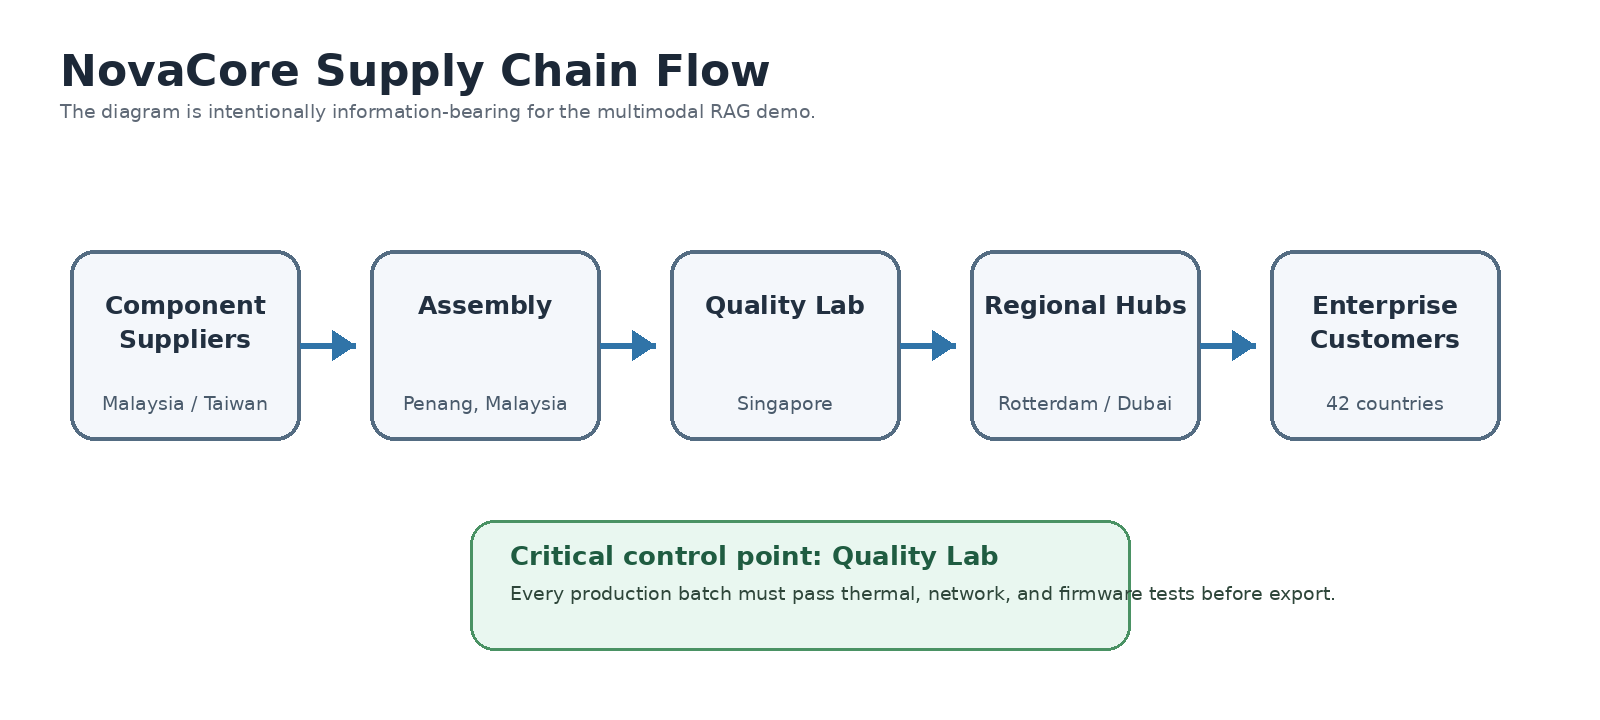

{'answer': 'Based on the FY2026 report, here is a brief overview of NovaCore Systems Ltd.:\n\n**Company Overview**\n*   **Identity:** NovaCore Systems Ltd. is a company operating in the **Industrial AI & IoT** sector.\n*   **Scale:** The company has **1,480 employees** and serves enterprise customers in **42 countries**.\n*   **Financials:** In 2026, the company reported a revenue of **$132.0M** with an operating margin of **18.4%**.\n*   **Location:** The headquarters is located in **Singapore** (Page 1).\n\n**Operations & Supply Chain**\n*   **Process:** The supply chain follows a linear flow: Component Suppliers (Malaysia/Taiwan) $\\rightarrow$ Assembly (Penang, Malaysia) $\\rightarrow$ Quality Lab (Singapore) $\\rightarrow$ Regional Hubs (Rotterdam/Dubai) $\\rightarrow$ Enterprise Customers (Page 6).\n*   **Quality Control:** The **Quality Lab in Singapore** is designated as the "critical control point." Every production batch must pass thermal, network, and firmware tests before e

In [156]:
ask("give me brief aboutNovacare ",show_images=True)
